Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load Dataset

In [3]:
df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 62.5+ KB


In [30]:
df['Dependents'].value_counts()

,count
Dependents,
0,360
1,102
2,101
3,51


In [31]:
# Replace '3+' with 3 and convert column to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

Handle Missing Values

In [32]:
# Numeric columns
numeric_cols = ['LoanAmount', 'Loan_Amount_Term', 'ApplicantIncome', 'CoapplicantIncome']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-198/2323782492.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-198/2323782492.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Encode Categorical Variables

In [33]:
label_cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

Check for Imbalanced Data

Loan_Status
1    422
0    192
Name: count, dtype: int64


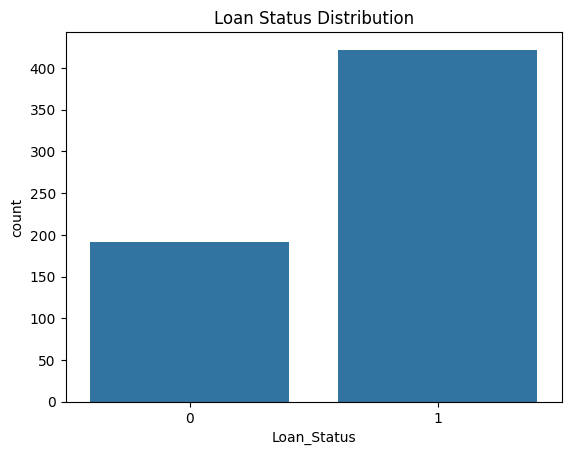

In [34]:
# Count target classes
print(df['Loan_Status'].value_counts())

# Visualize imbalance
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

Separate Features and Target

In [35]:
# Drop Loan_ID column as it is not a predictive feature
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']

Apply StandardScaler to Numeric Features

In [36]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

Split Data into Train and Test Sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures train/test have same ratio of classes

Visualize Key Features

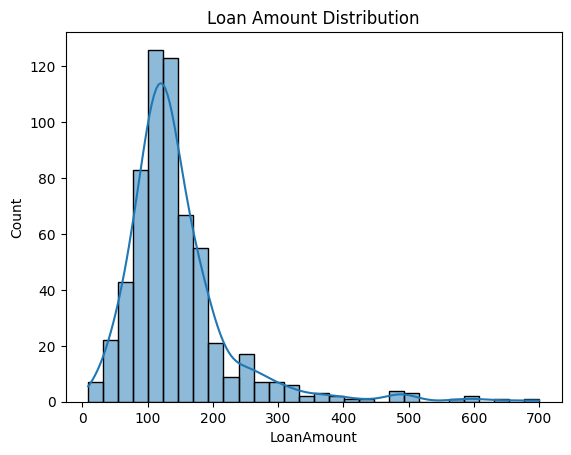

In [38]:
#Loan Amount Distribution
sns.histplot(df['LoanAmount'], kde=True, bins=30)
plt.title('Loan Amount Distribution')
plt.show()

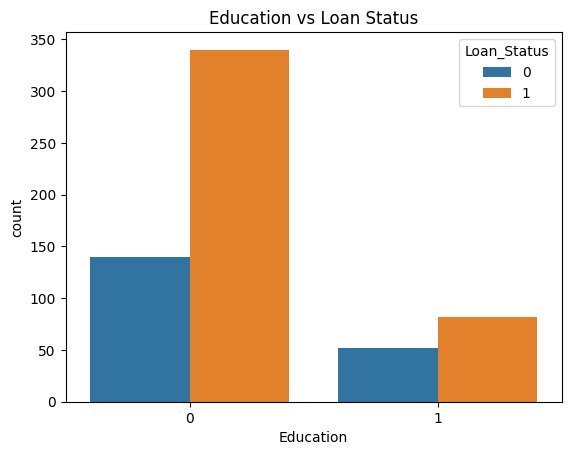

In [39]:
#Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Status')
plt.show()

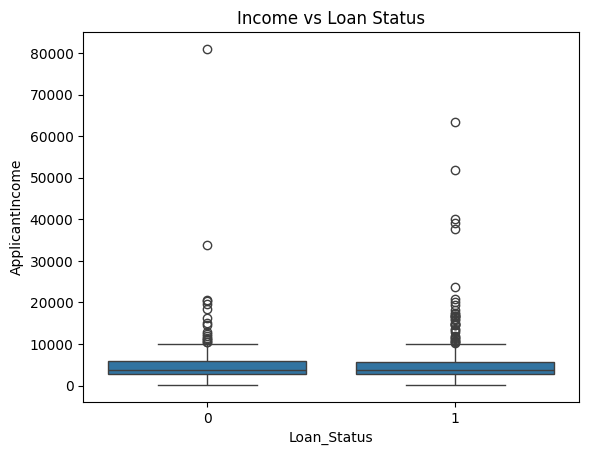

In [40]:
#Applicant Income vs Loan Status
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Income vs Loan Status')
plt.show()

Train Logistic Regression Model (with Class Balance Handling)

In [41]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')  # class_weight helps with imbalance
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Evaluate

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8048780487804879
Confusion Matrix:
 [[24 14]
 [10 75]]
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123

